# Heart Disease Prediction with Neural Networks (PyTorch)

**Dataset:** Heart Disease UCI (Cleveland)  
**Goal:** Classify whether a patient has heart disease based on clinical variables.

---

## Problem context

The dataset contains records from 303 patients at the Cleveland Clinic Foundation. Each row is a patient described by 13 clinical features. The original target indicates the degree of arterial narrowing (0 to 4). We binarize it: **0 = no disease, 1 = disease present**.

**Features:**
- `age` : age in years
- `sex` : sex (1 = male, 0 = female)
- `cp` : chest pain type (0-3)
- `trestbps` : resting blood pressure (mmHg)
- `chol` : serum cholesterol (mg/dl)
- `fbs` : fasting blood sugar > 120 mg/dl (1 = true)
- `restecg` : resting ECG result (0-2)
- `thalach` : maximum heart rate achieved
- `exang` : exercise-induced angina (1 = yes)
- `oldpeak` : ST depression induced by exercise
- `slope` : slope of the peak exercise ST segment (0-2)
- `ca` : number of major vessels colored by fluoroscopy (0-3)
- `thal` : thalassemia type (0 = normal, 1 = fixed defect, 2 = reversible defect)

---

## Project structure

```
projeto_doenca_cardiaca/
├── data/               # Raw dataset
├── models/             # Saved weights and scaler
├── notebooks/          # This notebook
├── reports/            # Outputs and reports
└── src/
    ├── preprocessing.py
    ├── model.py
    ├── evaluation.py
    └── persistence.py
```

API serving:

```
api/
├── main.py          # FastAPI endpoints
├── schemas.py       # Pydantic models
├── predictor.py     # Inference logic
├── Dockerfile
└── requirements.txt
```

## 1. Imports and setup

In [58]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from preprocessing import load_data, binarize_target, encode_features, split_and_scale
from model import MLP, Trainer
from evaluation import print_metrics, plot_training_history, plot_evaluation, plot_threshold_analysis
from persistence import save_model, save_scaler

print(f'PyTorch: {torch.__version__}')
print(f'Device:  {"cuda" if torch.cuda.is_available() else "cpu"}')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.3f}'.format)
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

PyTorch: 2.5.1+cu121
Device:  cuda


## 2. Loading and inspecting the data

UCI Cleveland dataset: https://archive.ics.uci.edu/ml/datasets/heart+disease

Expected file at `../data/heart.csv`.

In [59]:
df = load_data('../data/heart.csv')
df.head()

Linhas carregadas: 303 | Após remoção de NaN: 303


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.300,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.500,2,3,3,2
2,67,1,4,120,229,0,2,129,1,2.600,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.500,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.400,1,0,3,0


In [60]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000
mean,56.063,0.726,3.343,132.393,248.878,0.195,1.069,144.653,0.416,1.146,1.680,0.818,5.046,0.980
std,8.472,0.447,0.846,17.227,51.056,0.397,0.999,23.514,0.494,1.079,0.625,1.034,1.963,1.218
min,34.000,0.000,1.000,94.000,120.000,0.000,0.000,71.000,0.000,0.000,1.000,0.000,3.000,0.000
25%,51.000,0.000,3.000,120.000,211.500,0.000,0.000,129.000,0.000,0.100,1.000,0.000,3.000,0.000
50%,57.000,1.000,4.000,130.000,245.000,0.000,2.000,150.000,0.000,1.000,2.000,0.000,6.000,0.000
75%,62.000,1.000,4.000,140.000,283.000,0.000,2.000,162.000,1.000,1.800,2.000,1.000,7.000,2.000
max,76.000,1.000,4.000,200.000,417.000,1.000,2.000,194.000,1.000,6.200,3.000,4.000,7.000,4.000


In [61]:
print(f'Shape: {df.shape}')
print(f'\nValores nulos por coluna:')
print(df.isnull().sum())

Shape: (303, 14)

Valores nulos por coluna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## 3. Exploratory data analysis

In [62]:
# Binarize the target before EDA
df = binarize_target(df)

Distribuição do target:
target
0   0.525
1   0.475
Name: proportion, dtype: float64


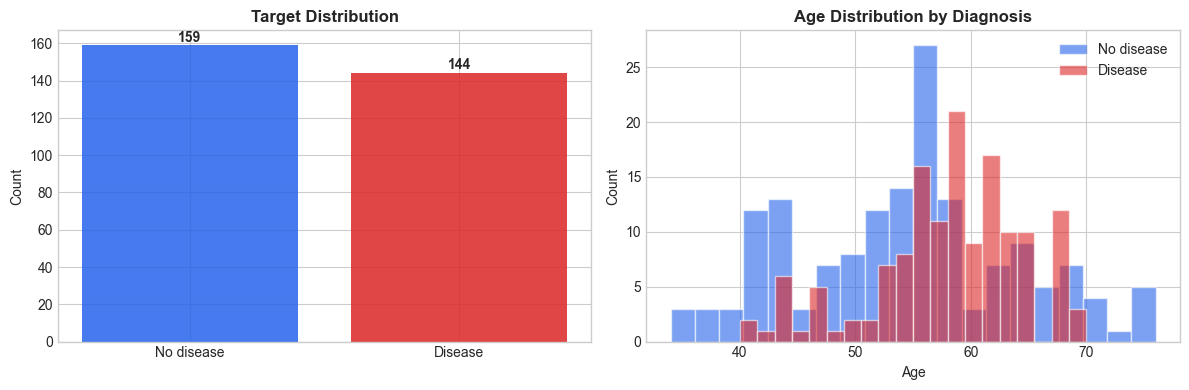

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution
# Sort by index to guarantee order [0, 1] after binarization
contagem = df['target'].value_counts().sort_index()
axes[0].bar(['No disease', 'Disease'], contagem.values, color=['#2563EB', '#DC2626'], alpha=0.85)
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')
axes[0].set_title('Target Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Age distribution by target
for label, cor, nome in [(0, '#2563EB', 'No disease'), (1, '#DC2626', 'Disease')]:
    axes[1].hist(df[df['target'] == label]['age'], bins=20,
                 alpha=0.6, color=cor, label=nome, edgecolor='white')
axes[1].set_title('Age Distribution by Diagnosis', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

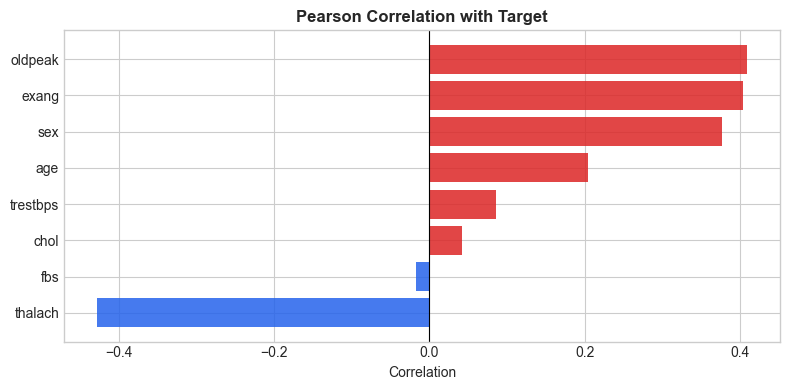

In [64]:
# Pearson correlation of numerical features with the target
from preprocessing import CONTINUOUS_FEATURES, BINARY_FEATURES

features_num = CONTINUOUS_FEATURES + BINARY_FEATURES
corr = df[features_num + ['target']].corr()['target'].drop('target').sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
cores = ['#DC2626' if c > 0 else '#2563EB' for c in corr.values]
ax.barh(corr.index, corr.values, color=cores, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with Target', fontweight='bold')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

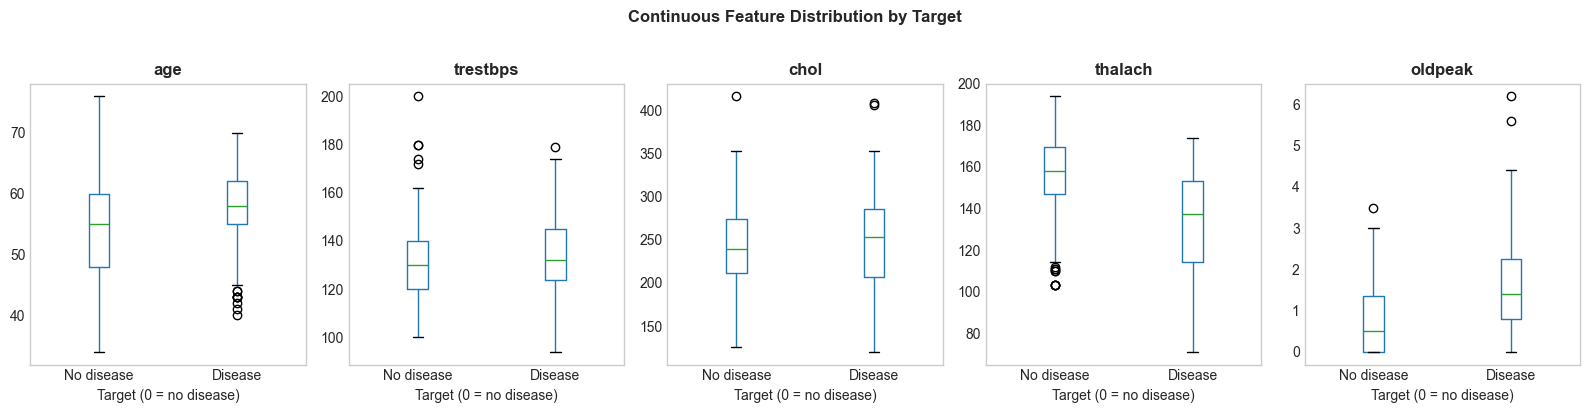

In [65]:
# Boxplots of continuous features by target
fig, axes = plt.subplots(1, len(CONTINUOUS_FEATURES), figsize=(16, 4))

for ax, feat in zip(axes, CONTINUOUS_FEATURES):
    df.boxplot(column=feat, by='target', ax=ax, grid=False)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Target (0 = no disease)')
    ax.set_xticklabels(['No disease', 'Disease'])

plt.suptitle('Continuous Feature Distribution by Target', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

**EDA notes:**
- The dataset is slightly imbalanced (~54% with disease), but not enough to require rebalancing techniques.
- `thalach` (max heart rate) has a strong negative correlation with disease: healthy patients reach higher heart rates.
- `oldpeak` and `ca` have the highest positive correlation with the diagnosis.
- The boxplot separation shows that several features are discriminative.

## 4. Preprocessing

In [66]:
X = encode_features(df)
y = df['target']

print(f'Features after encoding: {X.shape[1]}')
print(f'\nColumns:')
print(list(X.columns))

Features after encoding: 25

Columns:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'fbs', 'exang', 'cp_1', 'cp_2', 'cp_3', 'cp_4', 'restecg_0', 'restecg_2', 'slope_1', 'slope_2', 'slope_3', 'ca_0', 'ca_1', 'ca_2', 'ca_3', 'ca_4', 'thal_3', 'thal_6', 'thal_7']


In [67]:
(
    X_train, X_val, X_test,
    y_train, y_val, y_test,
    scaler, feature_names
) = split_and_scale(X, y, test_size=0.2, val_size=0.1, random_state=SEED)

input_dim = X_train.shape[1]
print(f'\nDimensão de entrada: {input_dim}')

Treino:    211 amostras
Validação: 31 amostras
Teste:     61 amostras

Dimensão de entrada: 25


## 5. Modeling

### Architecture

We use an MLP with two hidden layers. **Batch Normalization + Dropout** provide two complementary types of regularization:

- **BN** normalizes internal batch distributions, speeding up convergence and allowing higher learning rates. It keeps each layer operating in a stable region of the activation space, with pre-activations approximately normal before ReLU.
- **Dropout** with $p = 0.3$ creates a different sub-network on each forward pass, which is equivalent to averaging over an exponential ensemble of networks, reducing variance without much increase in bias.

**BCEWithLogitsLoss** fuses sigmoid and BCE into a single numerically stable operation (log-sum-exp), avoiding overflow when computing $\log(\sigma(x))$ for $x \gg 0$.

In [68]:
model = MLP(
    input_dim=input_dim,
    hidden_dims=[64, 32],
    dropout_rate=0.3
)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal de parâmetros: {total_params:,}')

MLP(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total de parâmetros: 3,969


## 6. Training

In [69]:
trainer = Trainer(
    model=model,
    lr=1e-3,
    weight_decay=1e-4   # L2 regularization in Adam
)

history = trainer.fit(
    X_train, y_train,
    X_val,   y_val,
    epochs=300,
    batch_size=32,
    patience=25,
    verbose=True
)

Epoch  20/300 | Train Loss: 0.4042 | Val Loss: 0.3938 | Val Acc: 0.8710 | LR: 1.00e-03
Epoch  40/300 | Train Loss: 0.2378 | Val Loss: 0.3080 | Val Acc: 0.9032 | LR: 1.00e-03
Epoch  60/300 | Train Loss: 0.2008 | Val Loss: 0.2836 | Val Acc: 0.9032 | LR: 1.00e-03
Epoch  80/300 | Train Loss: 0.1497 | Val Loss: 0.2936 | Val Acc: 0.8710 | LR: 5.00e-04

Early stopping na época 84 (sem melhora por 25 épocas).
Melhor val_loss: 0.2822 — pesos restaurados.


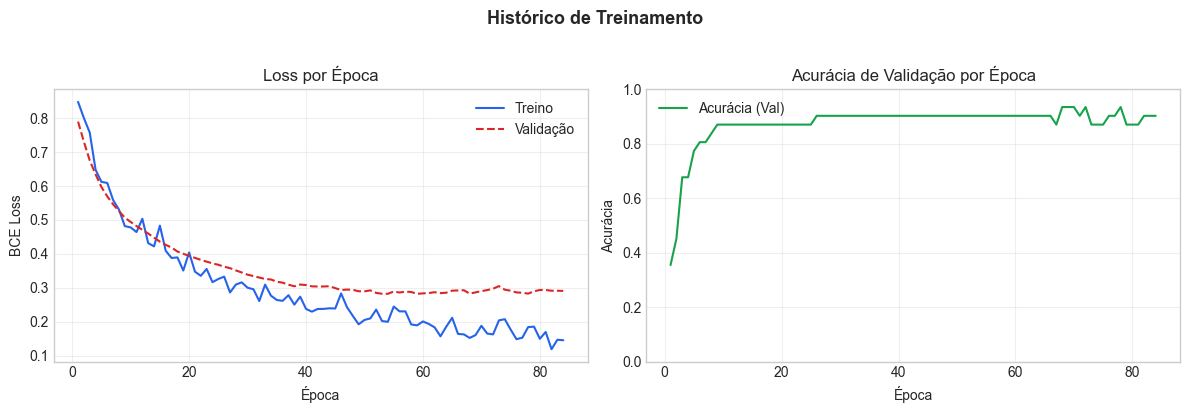

In [70]:
plot_training_history(history)

## 7. Evaluation on the test set

In [71]:
y_proba = trainer.predict_proba(X_test).numpy()

print('Metrics on the test set:')
print_metrics(y_test, y_proba)

Metrics on the test set:
AUC-ROC:           0.9321
Average Precision: 0.9357
              precision    recall  f1-score   support

  Sem doença       0.90      0.81      0.85        32
  Com doença       0.81      0.90      0.85        29

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61



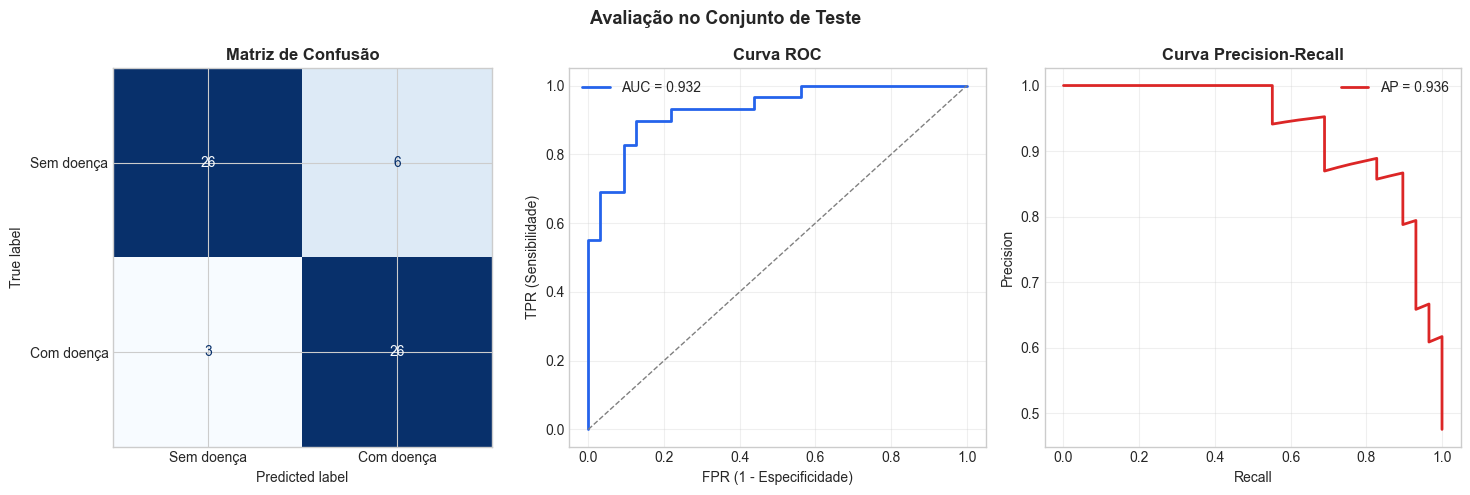

In [72]:
plot_evaluation(y_test, y_proba)

### Decision threshold analysis

In clinical problems, the cost of a **false negative** (predicting healthy when the patient is not) is typically much higher than a false positive. It is important to understand the Precision-Recall trade-off and pick a threshold based on that, rather than defaulting to 0.5.

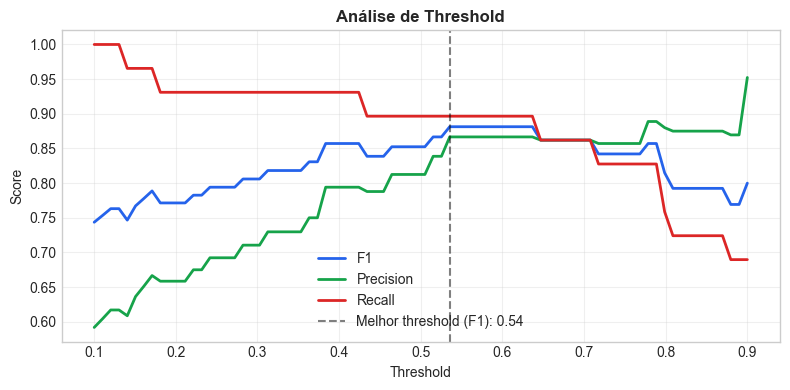

Threshold que maximiza F1: 0.535 (F1 = 0.8814)

Reavaliando com threshold 0.54:
AUC-ROC:           0.9321
Average Precision: 0.9357
              precision    recall  f1-score   support

  Sem doença       0.90      0.88      0.89        32
  Com doença       0.87      0.90      0.88        29

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [73]:
best_threshold = plot_threshold_analysis(y_test, y_proba)

print(f'\nReavaliando com threshold {best_threshold:.2f}:')
print_metrics(y_test, y_proba, threshold=best_threshold)

## 8. Artifact persistence

In [74]:
save_model(model,   '../models/mlp_heart.pt')
save_scaler(scaler, '../models/scaler.pkl')

Pesos salvos em: ../models/mlp_heart.pt
Scaler salvo em: ../models/scaler.pkl


## 9. Inference example (simulating production)

How inference would look in an API endpoint: receives a dictionary with patient data, applies the same transformation pipeline, and returns the probability.

In [75]:
import torch
import numpy as np
from persistence import load_model, load_scaler
from preprocessing import CONTINUOUS_FEATURES

def predict_new_patient(
    patient_features: np.ndarray,
    model_path: str,
    scaler_path: str,
    input_dim: int,
    hidden_dims: list,
    threshold: float = 0.5
) -> dict:
    """
    Simulates production inference.
    patient_features: array already in the same format as X_test.
    """
    from model import MLP

    # Load artifacts
    m = MLP(input_dim=input_dim, hidden_dims=hidden_dims)
    m = load_model(m, model_path)
    sc = load_scaler(scaler_path)

    # Apply scaler only to continuous features (indices 0:5)
    features = patient_features.copy().astype(float)
    features[:, :len(CONTINUOUS_FEATURES)] = sc.transform(
        features[:, :len(CONTINUOUS_FEATURES)]
    )

    # Inference
    with torch.no_grad():
        x = torch.tensor(features, dtype=torch.float32)
        prob = torch.sigmoid(m(x)).item()

    return {
        'disease_probability': round(prob, 4),
        'diagnosis':           'Disease' if prob >= threshold else 'No disease'
    }


# Take one sample from the test set to demonstrate
sample = X_test[[0]]   # shape (1, input_dim), scaler already applied

# Scaler already applied to X_test, so we run inference directly
with torch.no_grad():
    prob = trainer.predict_proba(sample).item()

print(f'Disease probability: {prob:.4f}')
print(f'Diagnosis:           {"Disease" if prob >= 0.5 else "No disease"}')
print(f'True label:          {"Disease" if y_test[0] == 1 else "No disease"}')

Disease probability: 0.4601
Diagnosis:           No disease
True label:          No disease


## 10. Explainability with SHAP

SHAP (SHapley Additive exPlanations) assigns each feature a contribution to the prediction for a specific sample. The idea comes from game theory: the Shapley value of a feature is the weighted average of its marginal contribution across all possible feature coalitions.

In practice: if the model says a patient has an 80% chance of disease, SHAP explains how much each feature pushed that value up or down relative to the model's average prediction.

In [76]:
import shap

device = next(model.parameters()).device
model.eval()

# GradientExplainer requires output shape (batch, n_outputs).
# Our model returns (batch,), one scalar per sample.
# The wrapper adds the missing dimension without changing weights or behavior.
class ShapWrapper(torch.nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        out = self.base_model(x)
        return out.unsqueeze(1) if out.dim() == 1 else out

wrapped_model = ShapWrapper(model).to(device)

# Background: a subset of the training set used as the reference for SHAP values.
# It defines the baseline prediction. SHAP attributes deviations from this baseline
# to each individual feature.
background = torch.tensor(X_train[:100], dtype=torch.float32, device=device)
explainer  = shap.GradientExplainer(wrapped_model, background)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)
shap_values   = explainer.shap_values(X_test_tensor)

# GradientExplainer may return a list or a tensor with an extra dimension.
# Normalize to np.ndarray with shape (n_samples, n_features) before plotting.
if isinstance(shap_values, list):
    shap_values = shap_values[0]
if isinstance(shap_values, torch.Tensor):
    shap_values = shap_values.detach().cpu().numpy()
if shap_values.ndim == 3 and shap_values.shape[-1] == 1:
    shap_values = shap_values[..., 0]

if hasattr(explainer, 'expected_value'):
    explainer.expected_value = float(np.ravel(explainer.expected_value)[0])

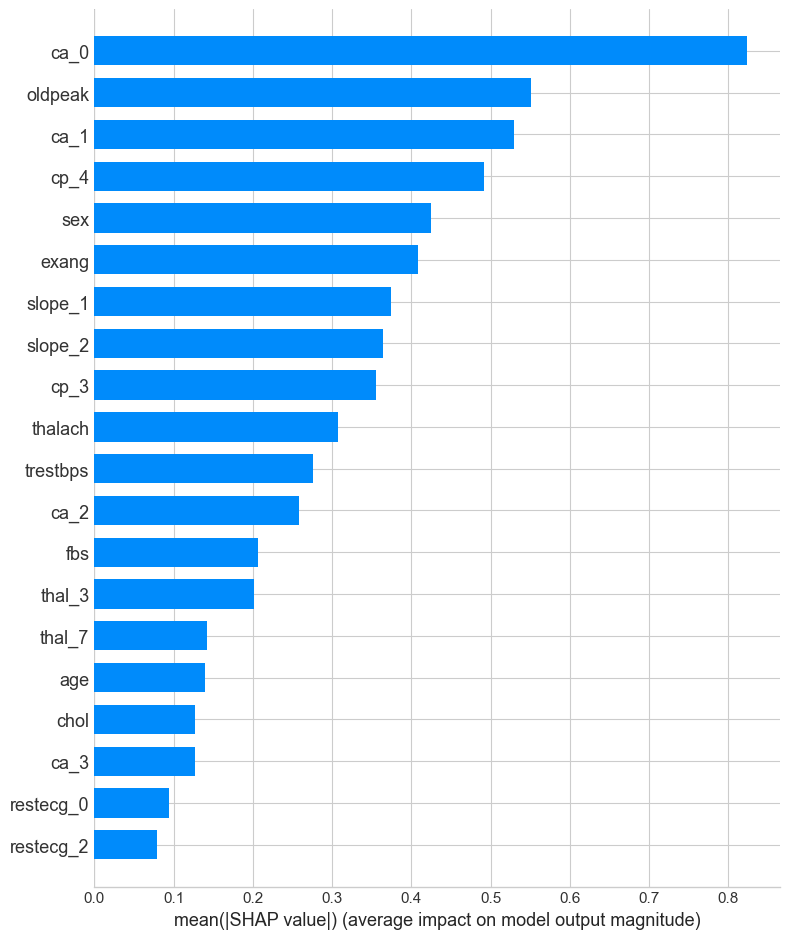

In [77]:
# Global importance: mean |SHAP value| per feature.
# Shows which features influence the model most on average across the test set.
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    plot_type='bar',
    show=True
)

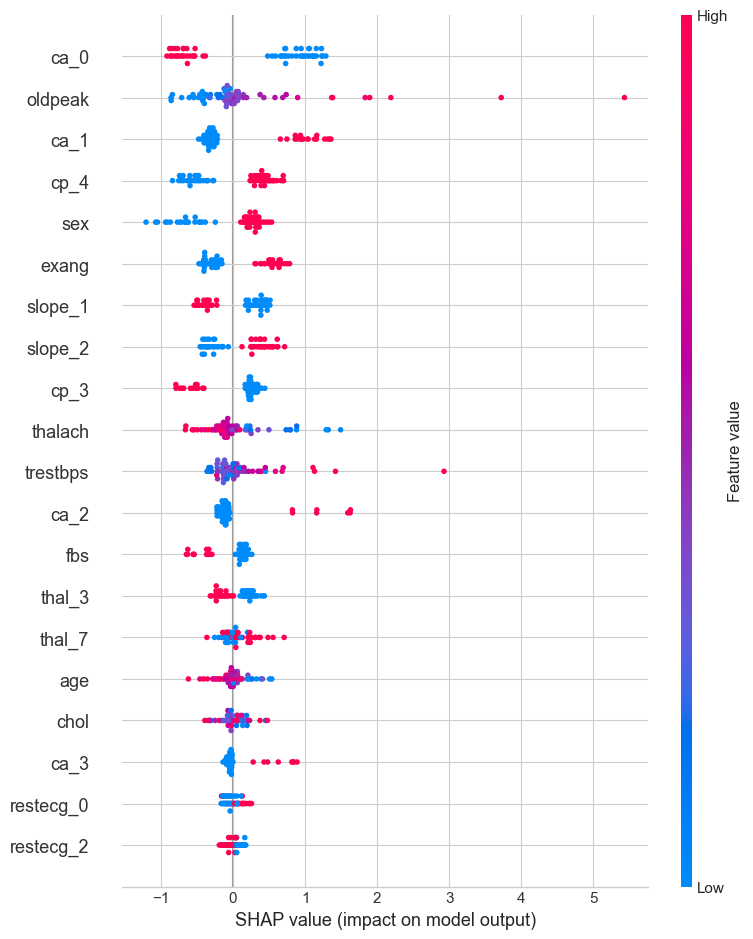

In [78]:
# Beeswarm plot: shows direction and magnitude of feature contributions.
# Each dot is a test sample. Color = feature value (high/low).
# Horizontal position = how much that value pushed the prediction up or down.
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    show=True
)

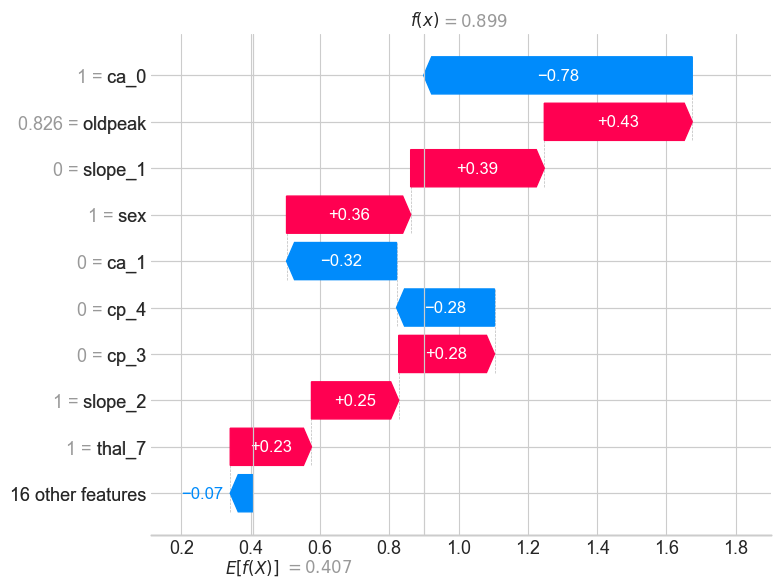

In [79]:
# GradientExplainer does not expose expected_value directly.
# We compute it as the mean prediction over the background set,
# which is the baseline from which SHAP contributions are measured.
with torch.no_grad():
    base_value = torch.sigmoid(
        wrapped_model(background)
    ).mean().item()

# Waterfall plot for a single patient: shows each feature's contribution
# to the final prediction, starting from the baseline.
idx = 0
shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[idx],
        base_values   = base_value,
        data          = X_test[idx],
        feature_names = feature_names
    )
)

## 11. Final remarks

### What worked well

- The network converged stably with early stopping. `ReduceLROnPlateau` helped avoid oscillations at the end of training.
- AUC-ROC above 0.90 is competitive for this dataset with simple neural networks, similar to results reported in the literature with other classifiers.

### Limitations

- The dataset has only ~300 samples. Neural networks are not necessarily the best choice at this scale; XGBoost or LightGBM often generalize better. The goal of this project is to demonstrate the PyTorch pipeline, not to maximize the score.
- There is no formal feature selection. With a small dataset, some one-hotted features may be adding noise.

### Next steps

1. **Model comparison:** run the same pipeline with XGBoost and compare AUC-ROC on the same fold.
2. **Hyperparameter tuning with Optuna:** tune `hidden_dims`, `dropout_rate`, `lr` and `batch_size` systematically.
3. **Calibration:** apply Platt scaling to ensure probabilities are well calibrated, which matters in clinical settings where the probability itself (not just the ranking) needs to be reliable.